# Corpus Masterclass 2: Dictionary-Based Content Analysis and Networks

A dictionary tags words with the categories they belong to. Applying one to a corpus tells us how much of each category appears in each document. This notebook applies the MAC virtue dictionary to the State of the Union corpus, plots category trends over time, and turns those percentages into a co-occurrence network. A final section repeats the analysis with the commercial LIWC dictionary on the instructor's local machine.

## Today's goal

1. Read a LIWC-format dictionary file.
2. Apply it to the State of the Union corpus for a per-speech table of category percentages.
3. Plot one moral-vocabulary category across two centuries.
4. Plot the remaining categories with a function called in a loop.
5. Compute an adjacency matrix: which categories co-occur across speeches.
6. Draw that adjacency as a network, with two layouts.

Dictionary: `dictionaries/macdvirtue.dic`, the Curry et al. MAC virtue dictionary.

In [1]:
# Libraries used throughout the notebook.
import sotu
import pandas
import numpy
import re
import liwc
import matplotlib.pyplot as plt
import networkx
from pathlib import Path

print('Libraries imported.')

Libraries imported.


In [2]:
# A LIWC-format dictionary has two parts. Between two lines that contain only '%', an
# id-to-name table declares the categories. After the second '%', each line is a term
# followed by the category ids it belongs to, all tab-separated. Look at the top of the
# file to see the shape.
with open('dictionaries/macdvirtue.dic') as f:
    line_number = 0
    for line in f:
        print(line.rstrip())
        line_number = line_number + 1
        if line_number >= 14:
            break

%
1	Family
2	Group
3	Reciprocity
4	Heroism
5	Deference
6	Fairness
7	Property
%
a favor	3
a favour	3
abase	5
abased	5
abasedly	5


In [3]:
# The liwc library reads the dictionary and handles the matching rules for us, including
# the trailing '*' wildcard (a term like 'tugend*' matches tugend, tugendhaft, and so on).
# load_token_parser returns a lookup function and the list of category names.
token_categories, category_names = liwc.load_token_parser('dictionaries/macdvirtue.dic')
print(f'Categories: {category_names}')

Categories: ['Family', 'Group', 'Reciprocity', 'Heroism', 'Deference', 'Fairness', 'Property']


In [4]:
# The lookup function returns the categories a token belongs to. A token can belong to
# none, one, or several categories.
for term in ['family', 'fair', 'brave', 'reciprocate']:
    print(f'{term}: {list(token_categories(term))}')

family: ['Family']
fair: []
brave: ['Heroism']
reciprocate: ['Reciprocity']


In [5]:
# Load the State of the Union corpus.
df = sotu.load()
print(f'{len(df)} speeches loaded.')

237 speeches loaded.


In [6]:
# Tokenise one speech and count how many tokens fall into each category. re.findall
# with the word pattern is a quick tokeniser for dictionary look-up.
first_tokens = re.findall(r'\w+', df.iloc[0]['text'].lower())

first_counts = {}
for name in category_names:
    first_counts[name] = 0
for token in first_tokens:
    for name in token_categories(token):
        first_counts[name] = first_counts[name] + 1

print(f'Washington 1790, category counts:')
print(first_counts)

Washington 1790, category counts:
{'Family': 0, 'Group': 2, 'Reciprocity': 1, 'Heroism': 2, 'Deference': 2, 'Fairness': 0, 'Property': 0}


`liwcalike` runs that same tally over every speech at once. It comes from `corpus_tools.py`. That file sits beside this notebook, and `import` brings its code in.

In [7]:
# import takes a name from another file and makes it usable here. corpus_tools.py sits in
# the same folder as this notebook. From it we take the liwcalike function.
from corpus_tools import liwcalike

# liwcalike tokenises each speech and tallies its dictionary categories, then divides every
# count by the speech's word count. A long speech uses more category words just by being
# longer, so comparing percentages rather than counts puts every speech on equal footing.
# liwcalike needs three things: the texts, a name for each speech, and the dictionary file.
docnames = []
for _, speech in df.iterrows():
    docnames.append(f"{speech['president']}_{speech['year']}")

virtue_df = liwcalike(list(df['text']), docnames, 'dictionaries/macdvirtue.dic')
virtue_df['year'] = list(df['year'])
virtue_df['president'] = list(df['president'])
print(f'{len(virtue_df)} speeches processed.')
virtue_df[['docname', 'WC', 'Family', 'Group']].head(3)

237 speeches processed.


,docname,WC,Family,Group
0,Washington_1790,1091,0.0,0.18
1,Washington_1790,1411,0.0,0.21
2,Washington_1791,2155,0.0,0.32


In [8]:
# Helper. Plot one category's percentage across the years.
def plot_category(category_name):
    ordered = virtue_df.sort_values('year')
    plt.figure(figsize=(13, 4))
    plt.plot(ordered['year'], ordered[category_name], marker='o', markersize=3, linewidth=0.6)
    plt.xlabel('Year')
    plt.ylabel(f'{category_name} (% of words)')
    plt.title(f'MAC virtue: {category_name} in State of the Union addresses')
    plt.show()

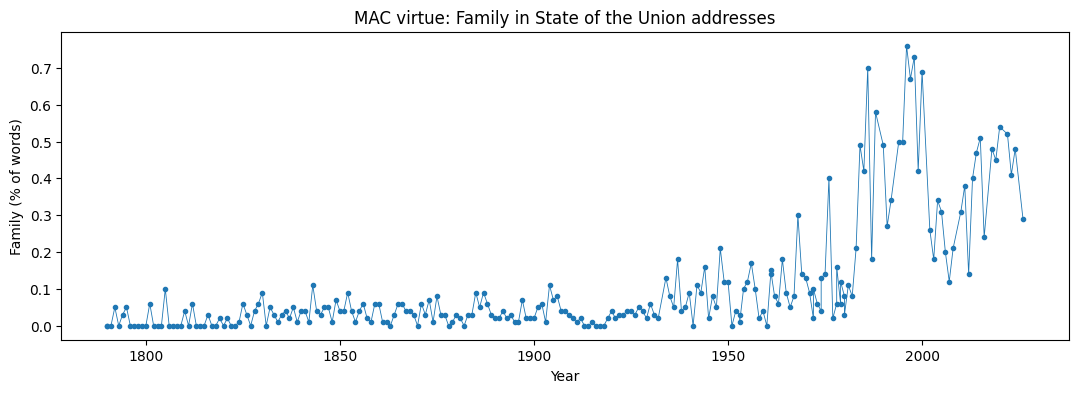

In [9]:
# Family across two centuries.
plot_category('Family')

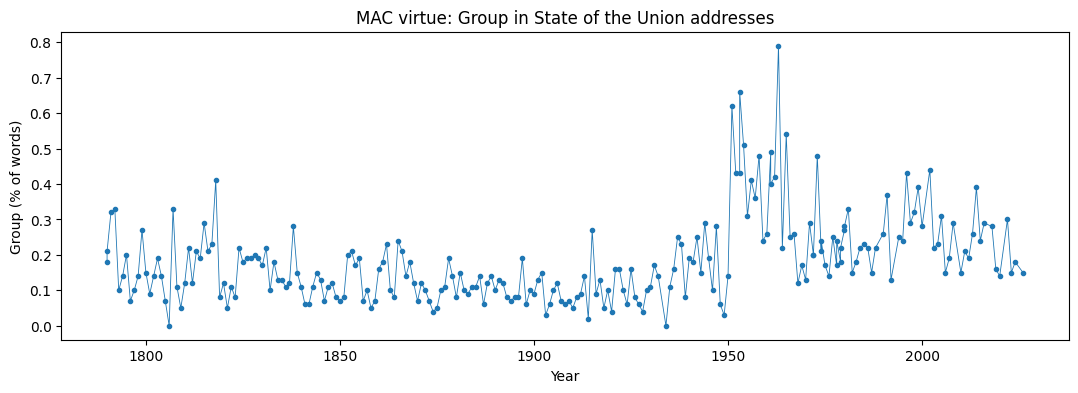

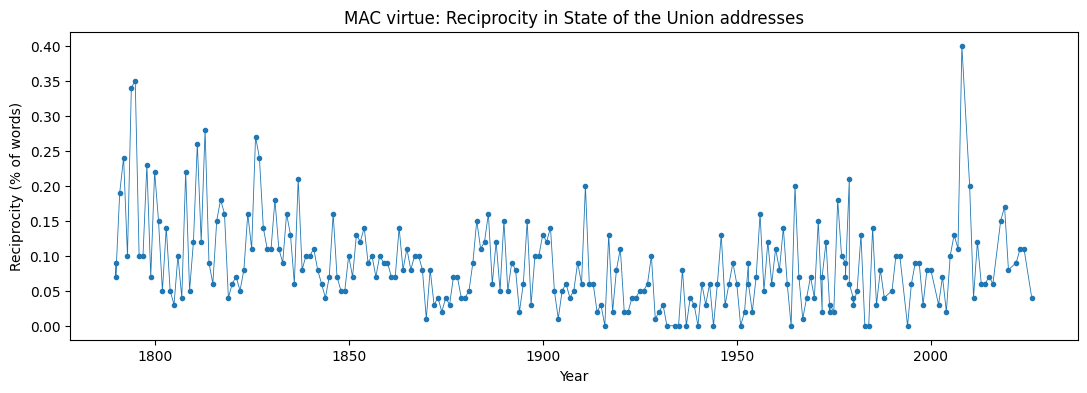

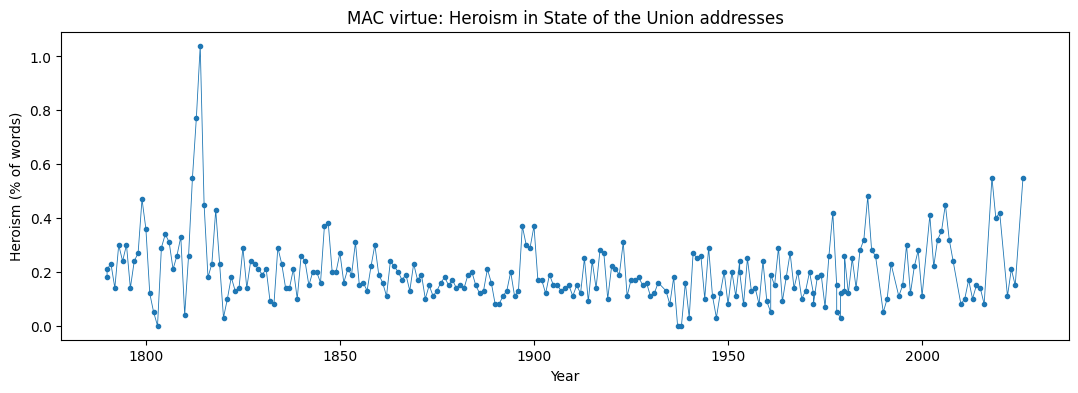

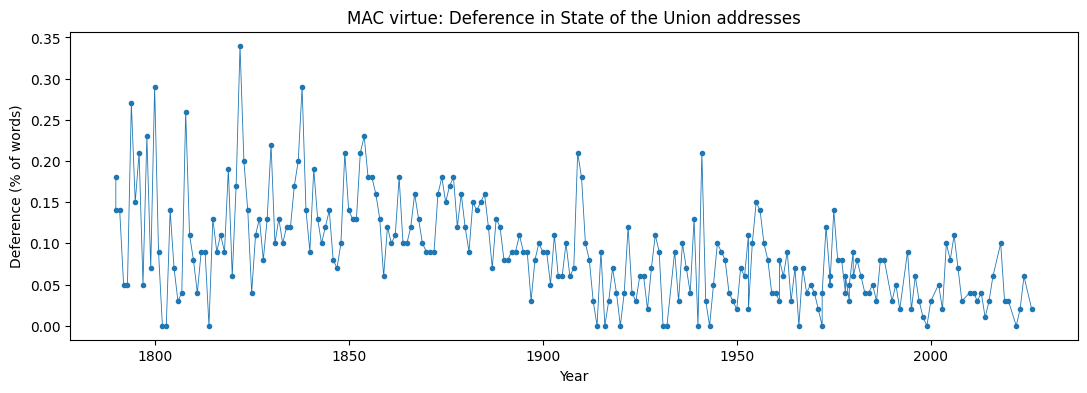

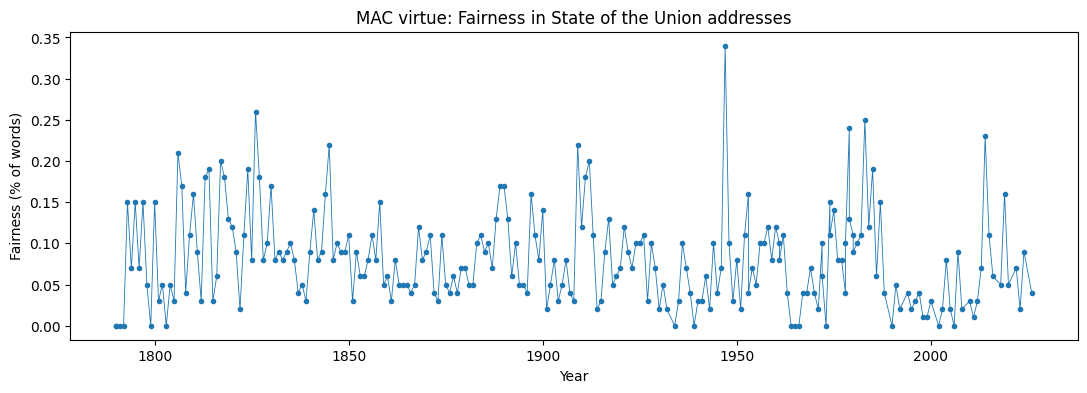

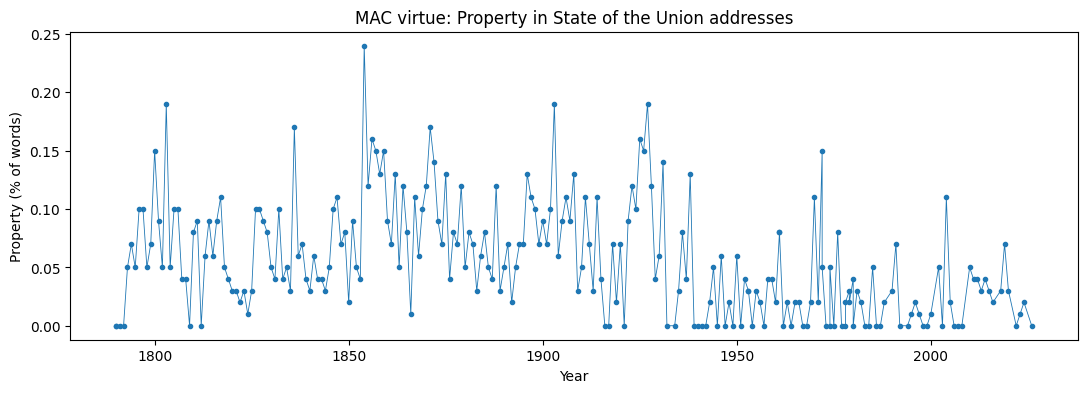

In [10]:
# Every remaining category, one call each, via a loop.
for name in ['Group', 'Reciprocity', 'Heroism', 'Deference', 'Fairness', 'Property']:
    plot_category(name)

In [11]:
# An adjacency matrix is a square table where rows and columns are the same items, here
# the seven virtues. Subset to the seven percentage columns and convert to a numpy array.
virtue_matrix = virtue_df[category_names].to_numpy()
print(f'Matrix shape: {virtue_matrix.shape}')

Matrix shape: (237, 7)


In [12]:
# Multiply the matrix transpose by the matrix. The result is 7 by 7. Each cell is large
# when two categories tend to appear in the same speeches.
adjacency = virtue_matrix.T @ virtue_matrix
pandas.DataFrame(adjacency, index=category_names, columns=category_names).round(2)

,Family,Group,Reciprocity,Heroism,Deference,Fairness,Property
Family,8.32,5.66,1.94,5.23,1.44,1.65,0.82
Group,5.66,11.13,3.83,8.70,3.54,3.35,1.94
Reciprocity,1.94,3.83,2.76,4.49,2.08,1.80,1.20
Heroism,5.23,8.70,4.49,12.75,4.26,3.88,2.58
Deference,1.44,3.54,2.08,4.26,2.81,1.79,1.31
Fairness,1.65,3.35,1.80,3.88,1.79,2.31,1.13
Property,0.82,1.94,1.20,2.58,1.31,1.13,1.27


In [13]:
# Build a network from the adjacency matrix. Relabel the integer nodes with category
# names and drop the self-loops created by the matrix diagonal.
graph = networkx.from_numpy_array(adjacency)
relabelling = {}
for node_index, name in enumerate(category_names):
    relabelling[node_index] = name
graph = networkx.relabel_nodes(graph, relabelling)
graph.remove_edges_from(list(networkx.selfloop_edges(graph)))
print(f'{graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges.')

7 nodes, 21 edges.


In [14]:
# Helper. Draw the network with a given layout and title. Co-occurrence weights vary
# widely, so scale every edge against the largest weight: the thickest edge is 8 points,
# the rest proportional. Edge transparency keeps overlapping lines readable.
def draw_network(graph, positions, title):
    weights = []
    for u, v in graph.edges():
        weights.append(graph[u][v]['weight'])
    largest = max(weights)
    widths = []
    for weight in weights:
        widths.append(weight / largest * 8)
    # Node area grows with strength: the total co-occurrence weight on a virtue, scaled
    # against the busiest virtue so the sizes stay sensible on percentage inputs.
    strengths = []
    for node in graph.nodes():
        strengths.append(graph.degree(node, weight='weight'))
    biggest = max(strengths) if max(strengths) > 0 else 1
    node_sizes = []
    for value in strengths:
        node_sizes.append(400 + value / biggest * 2600)
    plt.figure(figsize=(9, 8))
    networkx.draw(
        graph,
        pos=positions,
        with_labels=True,
        node_color='lightpink',
        node_size=node_sizes,
        edge_color='gray',
        width=widths,
        font_size=11,
    )
    plt.title(title)
    plt.show()

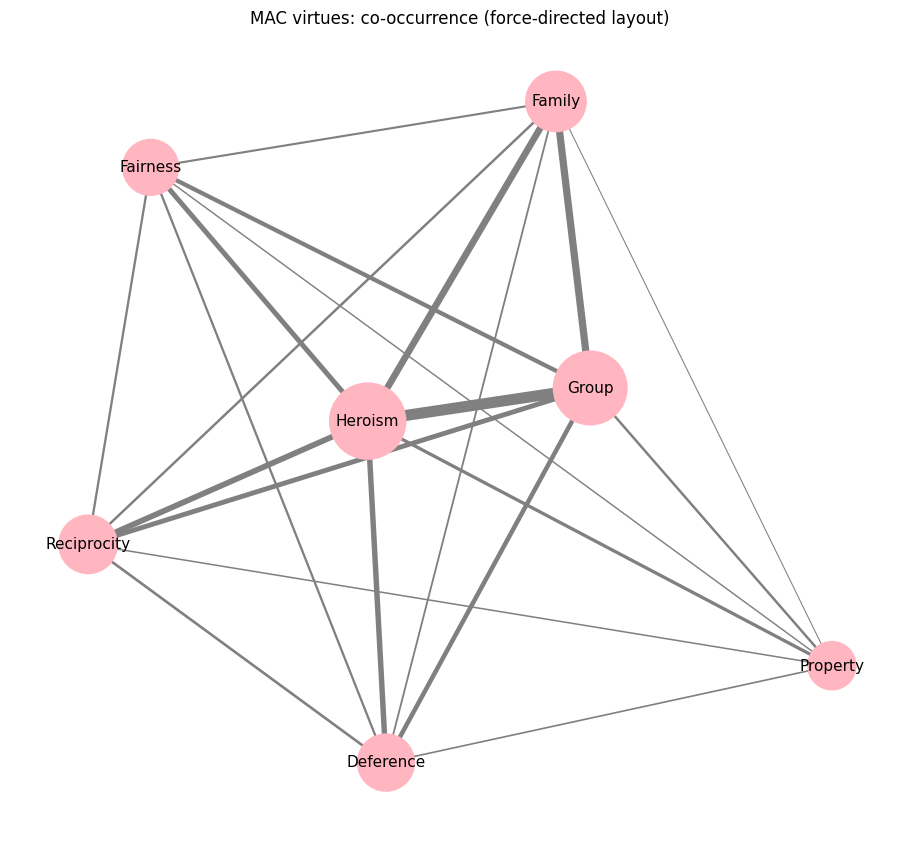

In [15]:
# A force-directed layout treats edges as springs. Connected nodes pull together;
# unconnected nodes drift apart.
spring_positions = networkx.spring_layout(graph, seed=42, weight='weight')
draw_network(graph, spring_positions, 'MAC virtues: co-occurrence (force-directed layout)')

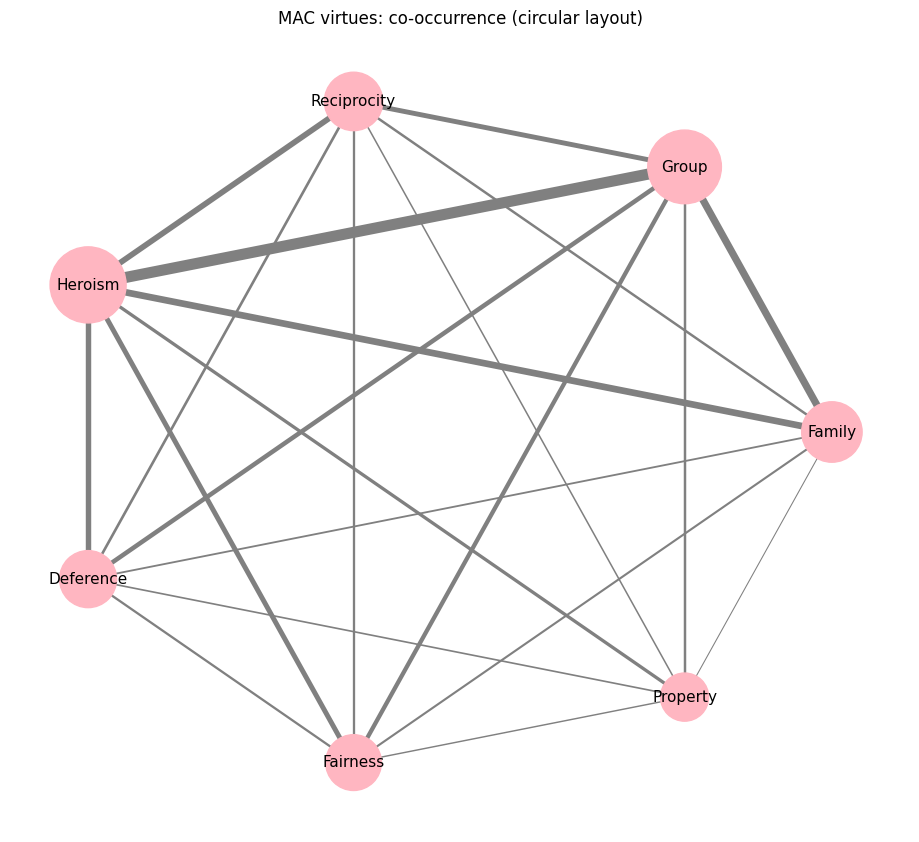

In [16]:
# A circular layout puts nodes evenly around a ring. Position carries no meaning here, so
# the eye reads edge thickness instead.
circular_positions = networkx.circular_layout(graph)
draw_network(graph, circular_positions, 'MAC virtues: co-occurrence (circular layout)')

## The commercial LIWC dictionary (instructor demo)

LIWC is the standard licensed psycholinguistic dictionary. The instructor runs it locally on `dictionaries/liwcdict.dic`. Because the file is commercial, it is never bundled in the public download; if it is not present here, the cells below skip themselves and the MAC analysis above stands in as the open-dictionary version of the same method.

In [17]:
# Try to load the LIWC dictionary. Path.exists() returns True if the file is on disk.
liwc_path = Path('dictionaries/liwcdict.dic')
have_liwc = liwc_path.exists()
if have_liwc:
    _, liwc_names = liwc.load_token_parser(str(liwc_path))
    print(f'LIWC dictionary loaded: {len(liwc_names)} categories.')
else:
    print('liwcdict.dic is commercial and licensed, so it is never bundled with this course.')
    print('To run this section, place your own licensed liwcdict.dic in the dictionaries/')
    print('folder beside this notebook. Without it, these LIWC cells skip and the open MAC')
    print('analysis above stands in as the same method on a free dictionary.')

LIWC dictionary loaded: 73 categories.


In [18]:
# liwcalike works with any LIWC-format dictionary, so the commercial file goes through the
# very same function. Six emotion categories mirror the 2025 lesson: overall affect,
# positive and negative emotion, then the three negative subtypes.
if have_liwc:
    emotion_categories = ['Affect', 'Posemo', 'Negemo', 'Anx', 'Anger', 'Sad']
    liwc_df = liwcalike(list(df['text']), docnames, str(liwc_path))
    liwc_df['year'] = list(df['year'])
    liwc_df = liwc_df.sort_values('year')
    print(liwc_df[['year', 'Affect', 'Posemo', 'Negemo']].head(3))
else:
    print('LIWC counts skipped.')

   year  Affect  Posemo  Negemo
0  1790    7.97    7.15    0.73
1  1790    6.45    4.89    1.42
2  1791    5.10    4.08    1.02


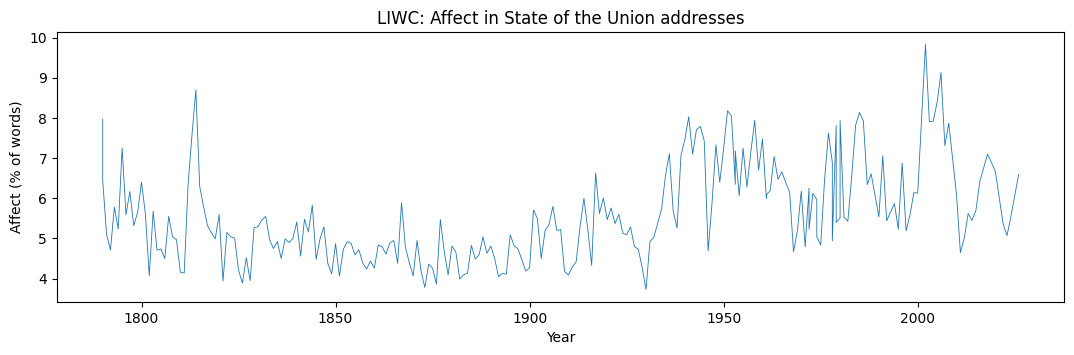

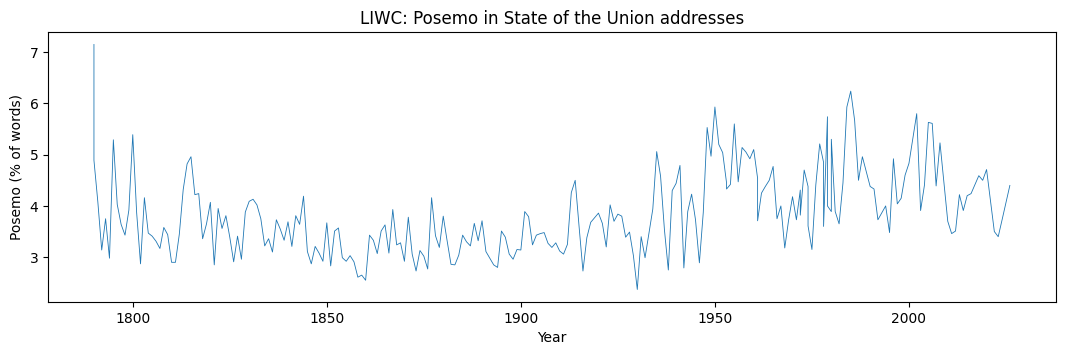

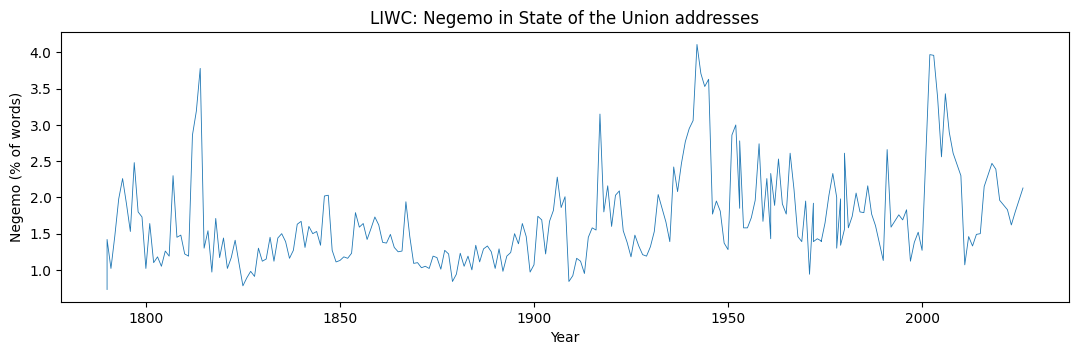

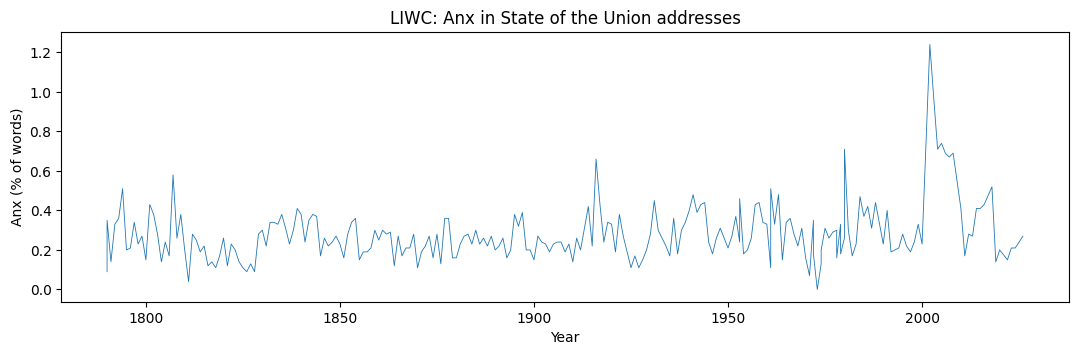

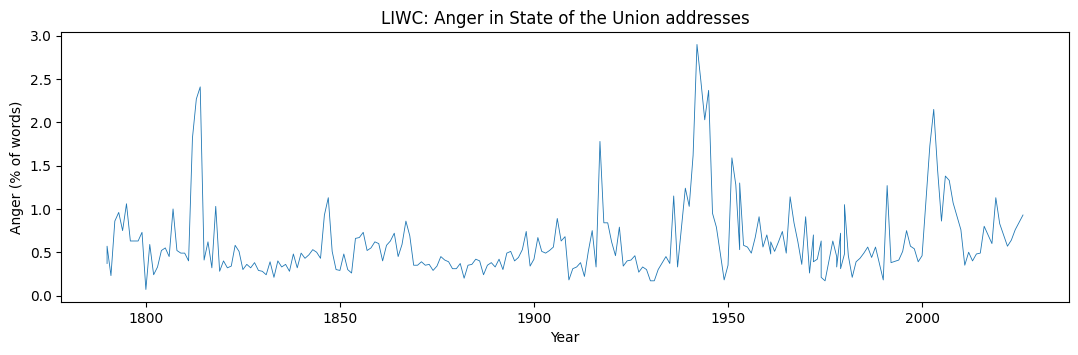

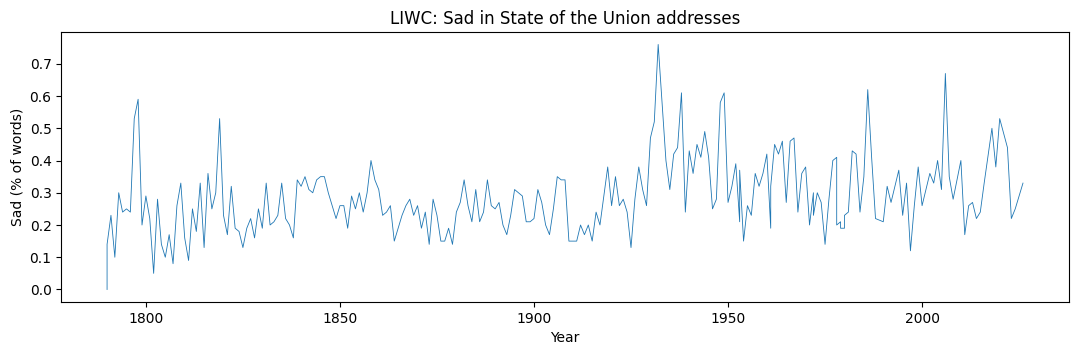

In [19]:
# Plot each emotion category across the years, via a function and a for loop. Same shape
# as plot_category above, applied to the LIWC categories.
if have_liwc:
    def plot_liwc(category_name):
        plt.figure(figsize=(13, 3.5))
        plt.plot(liwc_df['year'], liwc_df[category_name], linewidth=0.6)
        plt.xlabel('Year')
        plt.ylabel(f'{category_name} (% of words)')
        plt.title(f'LIWC: {category_name} in State of the Union addresses')
        plt.show()

    for name in ['Affect', 'Posemo', 'Negemo', 'Anx', 'Anger', 'Sad']:
        plot_liwc(name)
else:
    print('LIWC plots skipped.')

## What we've covered

**Python:** file reading with `with open`; `re.findall` for tokenisation; importing a function from a helper module with `import`; defining functions and calling them in a loop; numpy matrix transpose `.T` and matrix multiplication `@`; networkx graphs, layouts, and drawing.

**Corpus linguistics:** LIWC-format dictionaries; dictionary-based content analysis; per-document normalisation to a percentage; adjacency matrices from feature matrices; force-directed and circular network layouts.

## Read more

- **MAC virtue dictionary**: Curry, Mullins & Whitehouse (2019), [https://doi.org/10.1086/701478](https://doi.org/10.1086/701478).
- **NumPy linear algebra basics**: [https://numpy.org/doc/stable/user/quickstart.html#linear-algebra](https://numpy.org/doc/stable/user/quickstart.html#linear-algebra).
- **NetworkX tutorial**: [https://networkx.org/documentation/stable/tutorial.html](https://networkx.org/documentation/stable/tutorial.html).
- **NetworkX layouts**: [https://networkx.org/documentation/stable/reference/drawing.html#module-networkx.drawing.layout](https://networkx.org/documentation/stable/reference/drawing.html#module-networkx.drawing.layout).
- **Python re module**: [https://docs.python.org/3/library/re.html](https://docs.python.org/3/library/re.html).